# 🚦 Analyzing Traffic Accidents and Patterns in New York City Using NYPD Data


## 📝 Project Overview

This project analyzes traffic accidents in **New York City (NYC)** using the **NYPD Motor Vehicle Collisions** dataset.  
The goal is to uncover **patterns**, identify **high-risk locations**, and analyze **accident severity** based on factors such as **safety equipment usage**, **driver demographics**, and **temporal trends**.


### 🔍 Research Questions:
- What are the most accident-prone areas in NYC?
- How do accident rates vary across **time**, **boroughs**, and **contributing factors**?
- How does **safety equipment usage** influence **accident severity**?
- Can we predict accident severity using **machine learning models**?


## 📊 Data

The data for this project is collected and maintained by the **New York Police Department (NYPD)** and is **updated daily**, ensuring **accuracy** and **reliability**.

### 💾 Data Sources & Formats:

1. **Crashes Data Table** *(CSV format)*:
   - Contains **~2 million** records of crash events.
   - **54 variables** including location, time, borough, and contributing factors.
   - [🔗 Data Link](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/about_data)

2. **Vehicles Data Table** *(CSV format)*:
   - Contains **~4 million** records of vehicles involved in crashes.
   - **25 variables** such as vehicle type, make, year, and contributing factors.
   - [🔗 Data Link](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Vehicles/bm4k-52h4/about_data)

3. **Person Data Table** *(JSON format)*:
   - Contains **~5 million** records of individuals involved in crashes (drivers, passengers, pedestrians).
   - **21 variables** including person type, injury status, age, and safety equipment used.
   - [🔗 Data Link](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Person/f55k-p6yu/about_data)

---



### 🧩 Data Integration:

- These datasets are **linked** by a common identifier: **`collision_id`**.
- Merging the **Crashes**, **Vehicles**, and **Person** datasets allows a **comprehensive analysis** of each accident:
  - **Crashes**: Context of the event.
  - **Vehicles**: Details of involved vehicles.
  - **Person**: Information about individuals involved.

---

This combination allows for in-depth analysis of **accident severity**, **contributing factors**, and **safety equipment effectiveness**.

## 💡 Motivation

- **Traffic accidents** pose significant safety, economic, and social challenges in urban areas like **New York City**.
- Understanding **where, when, and why** these accidents occur can help **prevent future incidents**.
- Analyzing the **impact of safety equipment** and other factors can guide **policy-making** and **public safety campaigns**.
- Leveraging **data-driven insights** allows city planners and law enforcement to **optimize interventions** and improve **road safety** for all commuters.


## ⚙️ Data Analysis Techniques:

- **Data Cleaning**:
  - Handling **missing values** and **categorical inconsistencies** (e.g., borough names, safety equipment).
  - **Merging datasets** (Crashes, Vehicles, Persons).

- **Feature Engineering**:
  - Creating **severity scores** by combining **emotional status** and **bodily injury**.
  - Bucketing:
    - **Time of day** (Morning, Afternoon, Evening, Night).
    - **Age groups** (<18, 18‑25, 26‑40, 41‑60, 61+).
    - **Severity levels** (No Injury, Minor, Moderate, Severe, Death).

- **Visualization**:
  - **Interactive heatmaps** (Plotly) for boroughs, age groups, and severity rates.
  - **Bar charts** (Matplotlib, Plotly) for accident frequencies, contributing factors, and severity distribution.

- **Statistical Testing**:
  - **Chi-square tests** to assess relationships between variables (e.g., borough vs. time of day).

- **Machine Learning (Question 3)**:
  - **LightGBM** for predicting **accident severity**.
  - **Optuna** for hyperparameter optimization.
  - **SHAP values** for explaining model predictions (feature importance).

---

## 📚 Python Libraries:

- **pandas** – Data cleaning, manipulation, and analysis.
- **numpy** – Numerical operations and array handling.
- **matplotlib** – Static data visualizations (plots, charts).
- **seaborn** – Statistical data visualizations (heatmaps, bar plots).
- **plotly** – Interactive charts and heatmaps.
- **scipy.stats (chi2_contingency)** – Statistical tests (Chi-square test).
- **lightgbm** – Gradient boosting model for severity prediction.
- **optuna** – Hyperparameter tuning for machine learning models.
- **shap** – Model interpretability (feature importance visualization).

---

**These tools and techniques helped us clean, analyze, and visualize** NYC accident patterns, **providing actionable insights** for road safety improvements. 🚦📊


### Importing Required Libraries

In [139]:
!pip install plotly statsmodels nbformat lightgbm optuna shap scipy tabulate


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\sanch\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [140]:
import pandas as pd
import numpy as np
from datetime import datetime
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import seaborn as sns
from tabulate import tabulate

import lightgbm as lgb
import optuna, shap, matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.calibration import CalibrationDisplay

In [141]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib
matplotlib.rcParams.update({'figure.max_open_warning': 0})


### 🔄 Data Loading & Preprocessing

This section loads the **three datasets**—**Crashes (CSV)**, **Vehicles (CSV)**, and **Persons (JSON)**—and performs **initial data cleaning**:

- Standardizes **column names**.
- Handles **missing values**.
- Merges datasets for a **comprehensive view** of each collision event.


In [142]:
crash_dtypes = {
    "COLLISION_ID": "int32",
    "CRASH DATE": "string",
    "CRASH_TIME": "string",
    "BOROUGH": "category",
    "ON_STREET_NAME": "string",
    "LATITUDE": "float32",
    "LONGITUDE": "float32",
    "NUMBER_OF_MOTORIST_INJURED": "Int8",
    "NUMBER_OF_MOTORIST_KILLED": "Int8",
    "CONTRIBUTING_FACTOR_VEHICLE_1": "category",
    "CONTRIBUTING_FACTOR_VEHICLE_2": "category",
}

vehicle_dtypes = {
    "COLLISION_ID": "int32",
    "UNIQUE_ID": "int32",
    "VEHICLE_TYPE": "category",
    "VEHICLE_MAKE": "category",
    "VEHICLE_YEAR": "Int64",              
    "VEHICLE_OCCUPANTS": "Int8",          
    "DRIVER_SEX": "category",
    "DRIVER_LICENSE_STATUS": "category",
}

person_dtypes = {
    "COLLISION_ID": "int32",
    "VEHICLE_ID": "int32",
    "UNIQUE_ID": "int32",
    "PERSON_TYPE": "category",
    "PERSON_SEX": "category",
    "PERSON_INJURY": "category",
    "BODILY_INJURY": "category",
    "PERSON_AGE": "Int8",                
    "EMOTIONAL_STATUS": "category",
    "SAFETY_EQUIPMENT": "category",
    "POSITION_IN_VEHICLE": "category",
}


In [143]:
parse_dates = ["CRASH DATE"]

crashes = pd.read_csv(
    "Crashes.csv",
    dtype=crash_dtypes,
    parse_dates=parse_dates,
    low_memory=False
)


crashes = crashes[
    (crashes['CRASH DATE'].dt.year >= 2014) &
    (crashes['CRASH DATE'].dt.year <= 2024)
]

# Load and filter Vehicles
vehicles = pd.read_csv(
    "Vehicles.csv",
    dtype=vehicle_dtypes,
    parse_dates=["CRASH_DATE"],
    low_memory=False
)

vehicles = vehicles[
    (vehicles['CRASH_DATE'].dt.year >= 2014) &
    (vehicles['CRASH_DATE'].dt.year <= 2024)
]

# Load and filter Persons
persons = pd.read_json(
    "Person_data.json",
    dtype=person_dtypes,
    lines=True
)

# Convert the date column to datetime
persons['CRASH_DATE'] = pd.to_datetime(persons['CRASH_DATE'], errors='coerce')

# Filter on year
persons = persons[
    (persons['CRASH_DATE'].dt.year >= 2014) &
    (persons['CRASH_DATE'].dt.year <= 2024)
]

### Normalize Column Names

In [144]:
for df in (crashes, vehicles, persons):
    df.columns = (
        df.columns.str.lower()
                   .str.strip()
                   .str.replace(" ", "_", regex=False)
    )


### 🔗 Merging Datasets

The **Crashes**, **Vehicles**, and **Persons** datasets are merged on the common identifier **`collision_id`** to create a **combined dataset**.  
This ensures we can analyze **each crash event** with its associated **vehicle** and **person** data.


In [145]:

# Subset relevant columns from each dataset
crash_sub = crashes[[
    "collision_id", "crash_date", "crash_time", "borough", "on_street_name",
    "latitude", "longitude", "number_of_motorist_injured", "number_of_motorist_killed",
    "contributing_factor_vehicle_1", "contributing_factor_vehicle_2"
]]

vehicle_sub = vehicles[[
    "collision_id", "unique_id", "vehicle_type", "vehicle_make", "vehicle_year",
    "vehicle_occupants", "driver_sex", "driver_license_status"
]]

person_sub = persons[[
    "collision_id", "vehicle_id", "unique_id", "person_type", "person_sex",
    "person_injury", "bodily_injury", "person_age", "emotional_status",
    "safety_equipment", "position_in_vehicle"
]]

# Merge crash and vehicle data
merged_veh_crash = pd.merge(crash_sub, vehicle_sub, on='collision_id', how='inner')
merged_veh_crash.rename(columns={'unique_id': 'vehicle_id'}, inplace=True)

# Merge above combined data with person data
combined_df = pd.merge(merged_veh_crash, person_sub, on=['collision_id', 'vehicle_id'], how='inner')


### Cleaning and Enrichment

In [146]:
# === 🧹 Data Cleaning and Feature Engineering ===

# 🎯 Combine crash date and time into a single datetime column
combined_df['crash_datetime'] = pd.to_datetime(
    combined_df['crash_date'].astype(str) + ' ' + combined_df['crash_time'],
    errors='coerce'
)

# 🎯 Filter data to only include years between 2014 and 2024
combined_df = combined_df[combined_df['crash_datetime'].dt.year.between(2014, 2024)]

# 🎯 Ensure latitude and longitude are numeric (invalid values become NaN)
combined_df['latitude'] = pd.to_numeric(combined_df['latitude'], errors='coerce')
combined_df['longitude'] = pd.to_numeric(combined_df['longitude'], errors='coerce')

# 🎯 Fill missing boroughs with 'Not Reported'
combined_df['borough'] = combined_df['borough'].cat.add_categories('Not Reported').fillna('Not Reported')

# 🎯 Fill missing on-street names with 'Not Reported'
combined_df['on_street_name'] = combined_df['on_street_name'].fillna('Not Reported')

# 🎯 Fill missing driver sex and license status with 'Not Reported'
combined_df['driver_sex'] = combined_df['driver_sex'].cat.add_categories('Not Reported').fillna('Not Reported')
combined_df['driver_license_status'] = combined_df['driver_license_status'].cat.add_categories('Not Reported').fillna('Not Reported')



###  Filtering + Transformation

In [147]:
# 🎯 Remove irrelevant or unknown safety equipment types
combined_df = combined_df[~combined_df['safety_equipment'].isin([
    "-", "Helmet (Motorcycle Only)", "Helmet Only (In-Line Skater/Bicyclist)",
    "Helmet/Other (In-Line Skater/Bicyclist)", "Pads Only (In-Line Skater/Bicyclist)",
    "Stoppers Only (In-Line Skater/Bicyclist)", "Unknown"
])]

# 🎯 Remove non-driver person types (focus only on vehicle drivers)
combined_df = combined_df[~combined_df['person_type'].isin([
    "Bicyclist", "Other Motorized", "Pedestrian"
])]

# 🎯 Convert 'safety_equipment' to binary categories ('Yes' if not 'None')
combined_df['safety_equipment'] = np.where(combined_df['safety_equipment'] == 'None', 'No', 'Yes')

# 🎯 Remove records with missing injury or emotional status data
combined_df = combined_df[combined_df['bodily_injury'].notna()]
combined_df = combined_df[combined_df['emotional_status'].notna()]


### Map scores

In [148]:
# 🎯 Map emotional status to numeric scores
combined_df['emotional_status_score'] = combined_df['emotional_status'].map({
    'Apparent Death': 12, 'Unconscious': 11, 'Incoherent': 10, 'Shock': 9,
    'Semiconscious': 8, 'Conscious': 7, 'Does Not Apply': 0, 'Unknown': 0
})

# 🎯 Map bodily injury locations to numeric scores
combined_df['bodily_injury_score'] = combined_df['bodily_injury'].map({
    'Entire Body': 12, 'Neck': 11, 'Back': 10, 'Head': 9,
    'Abdomen - Pelvis': 8, 'Chest': 7, 'Hip-Upper Leg': 6,
    'Shoulder - Upper Arm': 5, 'Knee-Lower Leg Foot': 4,
    'Elbow-Lower-Arm-Hand': 3, 'Eye': 2, 'Face': 1,
    'Does Not Apply': 0, 'Unknown': 0
})

# 🎯 Remove irrelevant or unusual vehicle positions
combined_df = combined_df[~combined_df['position_in_vehicle'].isin([
    "Riding/Hanging on Outside", 
    "If one person is seated on another person&apos;s lap", 
    "Does Not Apply"
])]


###  Clean Vehicle Positions

In [149]:
# Clean vehicle positions
# 🎯 Remove unused categories in 'position_in_vehicle'
combined_df['position_in_vehicle'] = combined_df['position_in_vehicle'].cat.remove_unused_categories()

# 🎯 Rename complex vehicle position categories for clarity
combined_df['position_in_vehicle'] = combined_df['position_in_vehicle'].cat.rename_categories({
    "Front passenger, if two or more persons, including the driver, are in the front seat": "Front Passenger not driver",
    "Right rear passenger or motorcycle sidecar passenger": "Right rear passenger",
    "Left rear passenger, or rear passenger on a bicycle, motorcycle, snowmobile": "Left rear passenger",
    "Any person in the rear of a station wagon, pick-up truck, all passengers on a bus, etc": "Rear (bus/truck/station wagon)",
    "Middle rear seat, or passenger lying across a seat": "Middle rear seat",
    "Middle front seat, or passenger lying across a seat": "Middle front seat"
})


###  Final Analysis Set + Severity Score 

In [150]:
# 🎯 Define columns to include in the final analysis dataset
analysis_cols = [
    "collision_id", "vehicle_id", "borough", "crash_date", "crash_time", "on_street_name",
    "contributing_factor_vehicle_1", "contributing_factor_vehicle_2", "latitude", "longitude",
    "vehicle_type", "vehicle_make", "vehicle_year", "vehicle_occupants",
    "driver_sex", "driver_license_status", "person_injury", "person_age",
    "safety_equipment", "position_in_vehicle", "emotional_status_score", "bodily_injury_score"
]

# 🎯 Create the final analysis dataset with selected columns
data = combined_df[analysis_cols].copy()

# 🎯 Focus only on drivers for analysis
data = data[data['position_in_vehicle'] == 'Driver']

### Add Time and Severity Buckets 


In [151]:
# 🎯 Extract crash hour from crash time
data['crash_hour'] = pd.to_datetime(data['crash_time'], format='%H:%M', errors='coerce').dt.hour

# 🎯 Calculate severity score (sum of emotional and bodily injury scores)
data['SEVERITY_SCORE'] = pd.to_numeric(data['emotional_status_score'], errors='coerce') + \
                         pd.to_numeric(data['bodily_injury_score'], errors='coerce')

# 🎯 Bin severity score into ordinal categories
bins = [0, 4, 9, 14, 19, 24]  # Define severity score ranges
labels = ['No Injury', 'Minor Accident', 'Moderate Accident', 'Severe Accident', 'Death']  # Define severity labels
data['SEVERITY_SCORE'] = pd.cut(data['SEVERITY_SCORE'], bins=bins, labels=labels, include_lowest=True)

# === Final Preview ===

# 🎯 Print dataset shape and preview first few rows
print(f"📊 Final dataset contains {data.shape[0]:,} rows and {data.shape[1]} columns.")
data.head()


📊 Final dataset contains 101,225 rows and 24 columns.


,collision_id,vehicle_id,borough,crash_date,crash_time,on_street_name,contributing_factor_vehicle_1,contributing_factor_vehicle_2,latitude,longitude,...,driver_sex,driver_license_status,person_injury,person_age,safety_equipment,position_in_vehicle,emotional_status_score,bodily_injury_score,crash_hour,SEVERITY_SCORE
2,4464159,20084242,BROOKLYN,2021-09-27,12:38,CENTRAL AVENUE,Failure to Yield Right-of-Way,Unspecified,40.687462,-73.906487,...,F,Licensed,Unspecified,40.0,Yes,Driver,0,0,12,No Injury
5,4516014,20197626,MANHATTAN,2022-03-30,23:30,EAST HOUSTON STREET,Driver Inattention/Distraction,Driver Inattention/Distraction,40.724136,-73.992615,...,M,Licensed,Unspecified,18.0,Yes,Driver,0,0,23,No Injury
6,4522133,20205691,Not Reported,2022-04-25,23:40,HARLEM RIVER DRIVE,Unsafe Lane Changing,Unspecified,40.814232,-73.934441,...,M,Licensed,Unspecified,51.0,Yes,Driver,0,0,23,No Injury
10,4493784,20146762,Not Reported,2022-01-10,16:13,CROSS BRONX EXPY,Following Too Closely,Unspecified,40.832535,-73.857971,...,M,Licensed,Unspecified,31.0,Yes,Driver,0,0,16,No Injury
13,4517591,20197908,BROOKLYN,2022-04-07,14:25,CHESTER STREET,Traffic Control Disregarded,Other Vehicular,40.659336,-73.909073,...,M,Licensed,Injured,47.0,Yes,Driver,7,10,14,Severe Accident


### Save as Parquet

In [152]:
data.to_parquet("nypd-collision-cleaned-2014-2024.parquet", index=False)
print("✅  Saved Parquet:", "final_processed_data.parquet",
      f"({data.shape[0]:,} rows × {data.shape[1]})")

✅  Saved Parquet: final_processed_data.parquet (101,225 rows × 24)


### Save as CSV

In [153]:
data.to_csv("nypd-collision-cleaned-2014-2024.csv", index=False)
print("✅ Final data has been saved to 'nypd-collision-cleaned-2014-2024.csv'")

✅ Final data has been saved to 'nypd-collision-cleaned-2014-2024.csv'


### Visualization On Pre-processed Data


#### Dynamic Heatmap with Year Slider

In [154]:
pio.templates.default = "plotly_white"

# === PREP: Parse time columns ===
data['crash_date'] = pd.to_datetime(data['crash_date'], errors='coerce')
data = data.dropna(subset=['latitude', 'longitude'])
data['year'] = data['crash_date'].dt.year

# === 🔄 Dynamic Heatmap (Year Slider) ===
heatmap_slider = px.density_mapbox(
    data,
    lat='latitude',
    lon='longitude',
    radius=5,
    center=dict(lat=40.7128, lon=-74.0060),
    zoom=9,
    mapbox_style='carto-positron',
    animation_frame='year',
    title='📍 NYC Accident Hotspots Over Time (2014–2024)',
    height=600
)
heatmap_slider.show()


### Donut Charts of Top Contributing Factors per Year

In [155]:
# Prep data
donut_data = data.groupby(['year', 'contributing_factor_vehicle_1']).size().reset_index(name='count')
years = sorted(donut_data['year'].unique())

# Create base figure
fig = go.Figure()

# Add one trace per year (but only show the first by default)
for i, yr in enumerate(years):
    df_year = donut_data[donut_data['year'] == yr].sort_values('count', ascending=False).head(10)
    visible = True if i == 0 else False
    fig.add_trace(go.Pie(
        labels=df_year['contributing_factor_vehicle_1'],
        values=df_year['count'],
        name=str(yr),
        hole=0.4,
        visible=visible,
        title=f"Top Contributing Factors - {yr}"
    ))

# Create dropdown buttons
dropdown_buttons = [
    dict(
        label=str(yr),
        method='update',
        args=[{'visible': [i == j for j in range(len(years))]},
              {'title': f"🍩 Top Contributing Factors in {yr}"}]
    )
    for i, yr in enumerate(years)
]

# Update layout with dropdown
fig.update_layout(
    updatemenus=[{
        'active': 0,
        'buttons': dropdown_buttons,
        'x': 0.5,
        'xanchor': 'center',
        'y': 1.1,
        'yanchor': 'top',
        'direction': 'down'
    }],
    title_text=f"🍩 Top Contributing Factors in {years[0]} (Select Year From DropDown)",
    height=600
)

fig.show()


### Monthly + Weekly Trends & Forecasting

In [156]:
# === Monthly Aggregation & Plot ===
data['month'] = data['crash_date'].dt.to_period('M')
monthly = data.groupby('month').size().reset_index(name='accidents')
monthly['month'] = pd.to_datetime(monthly['month'].astype(str))

fig_monthly = px.line(
    monthly, x='month', y='accidents', markers=True,
    title='📈 Monthly Traffic Accident Trend in NYC (2014–2024)'
)
fig_monthly.show()

# === Weekly Aggregation & Plot ===
data['week'] = data['crash_date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly = data.groupby('week').size().reset_index(name='accidents')
fig_weekly = px.line(
    weekly, x='week', y='accidents',
    title='📅 Weekly Traffic Accident Trend (2014–2024)'
)
fig_weekly.show()

# === Forecasting with ARIMA (Monthly) ===
ts = monthly.set_index('month')['accidents'].asfreq('MS').fillna(method='ffill')
model = ARIMA(ts, order=(1, 1, 1))
result = model.fit()


# ❓ Question 1:
**How do traffic accident patterns vary across NYC boroughs with respect to time of day and contributing factors?**  
This section investigates **borough-wise accident patterns** across different **times of day** (Morning, Afternoon, Evening, Night).  

We explore:
- Accident trends over the years.
- Which **boroughs** and **streets** experience the **highest accident frequencies** at different times of day.
- The **severity distribution** across boroughs and time periods.
- The **top contributing factors** (excluding unspecified) during each time of day.
- Whether there's a **statistically significant relationship** between borough and time of day (Chi-square test).

---


### 1.1 Import Libraries



In [157]:
# === STEP 1: Import Libraries ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


### 1.2 Clean Key Columns and Extract Hour

In [158]:
# 🧹 Clean and format key columns
clean = (
    data.assign(
        borough    = data['borough'].fillna('Not Reported').str.strip(),
        on_street  = data['on_street_name'].fillna('Not Reported').str.strip(),
        crash_hour = pd.to_datetime(data['crash_time'], format='%H:%M', errors='coerce').dt.hour
    )
)


### 1.3 Add Time-of-Day Buckets

In [159]:
# ⏰ Bucket crash hour into parts of the day
bins = [0, 5, 12, 17, 21, 24]
labels = ["Night", "Morning", "Afternoon", "Evening", "Late Night"]

clean['time_of_day'] = pd.cut(
    clean['crash_hour'].fillna(-1),
    bins=bins,
    labels=labels,
    right=False
)

# Optional: Set a fixed order for category labels
clean['time_of_day'] = clean['time_of_day'].cat.reorder_categories(labels, ordered=True)


### 1.4 Yearly Collision Count


In [160]:
# 📅 Count unique collisions by year
yearly_counts = (
    clean.drop_duplicates('collision_id')
         .groupby(clean['crash_date'].dt.year)['collision_id']
         .count()
         .rename('accident_count')
)


### 1.5 Top Boroughs & Streets

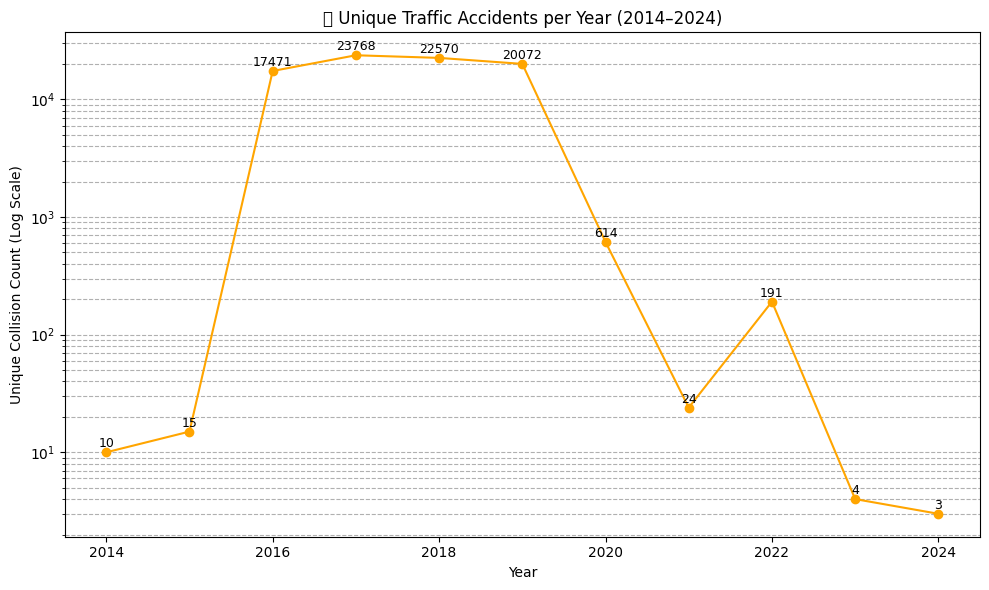

In [161]:

# --- Setup ---
data['on_street_name'] = data['on_street_name'].fillna('Not Reported').str.strip()
data['borough'] = data['borough'].fillna('Not Reported').str.strip()
data['crash_date'] = pd.to_datetime(data['crash_date'], errors='coerce')
data['crash_hour'] = pd.to_datetime(data['crash_time'], format='%H:%M', errors='coerce').dt.hour
data['year'] = data['crash_date'].dt.year

# --- Time of Day ---
time_bins = [(5, 12, 'Morning'), (12, 17, 'Afternoon'), (17, 21, 'Evening')]
data['time_of_day'] = data['crash_hour'].apply(
    lambda h: next((label for start, end, label in time_bins if start <= h < end), 'Night') if pd.notna(h) else 'Unknown'
)

# --- Unique Collisions per Year ---
yearly_counts = data.drop_duplicates('collision_id').groupby('year').size().reset_index(name='accident_count')

# --- Severity ---
data['severity_score'] = data['emotional_status_score'].fillna(0) + data['bodily_injury_score'].fillna(0)
bins = [0, 4, 9, 14, 19, 24]
labels = ['No Injury', 'Minor', 'Moderate', 'Severe', 'Death']
data['severity_level'] = pd.cut(data['severity_score'], bins=bins, labels=labels, include_lowest=True)

# --- Borough Time Heatmap Data (Exclude Not Reported) ---
heatmap_data = data[data['borough'].str.lower() != 'not reported']
heatmap_grouped = heatmap_data.groupby(['borough', 'time_of_day']).size().unstack(fill_value=0)
heatmap_grouped = heatmap_grouped.reindex(columns=["Morning", "Afternoon", "Evening", "Night"])

# --- PLOTS ---
# 1️⃣ Yearly Trend Plot
plt.figure(figsize=(10, 6))
plt.plot(yearly_counts['year'], yearly_counts['accident_count'], marker='o', color='orange')
plt.yscale('log')
for x, y in zip(yearly_counts['year'], yearly_counts['accident_count']):
    plt.text(x, y * 1.1, str(y), ha='center', fontsize=9)
plt.title("📈 Unique Traffic Accidents per Year (2014–2024)")
plt.xlabel("Year"); plt.ylabel("Unique Collision Count (Log Scale)")
plt.grid(True, which='both', axis='y', linestyle='--')
plt.tight_layout()
plt.show()





### 1.6  Top Boroughs & Streets

In [162]:

# === 📍 Top Boroughs & Streets (Styled Output) ===
time_order = ["Morning", "Afternoon", "Evening", "Night"]

cleaned = data[
    (data['on_street_name'].str.lower() != 'not reported') &
    (data['borough'].str.lower() != 'not reported')
]

top_boro = (
    cleaned.groupby(['time_of_day', 'borough']).size().reset_index(name='accident_count')
    .sort_values(['time_of_day', 'accident_count'], ascending=[True, False])
    .groupby('time_of_day').head(3)
)

rows = [
    {
        'Rank': i + 1,
        'Time of Day': t,
        'Borough': b,
        'Accident Count': c,
        'Top Street': cleaned.query("time_of_day == @t and borough == @b")['on_street_name'].value_counts().idxmax()
    }
    for t in time_order
    for i, (b, c) in enumerate(top_boro[top_boro['time_of_day'] == t][['borough', 'accident_count']].values)
]

top_streets_df = pd.DataFrame(rows)

styled_top_streets = top_streets_df.style \
    .background_gradient(cmap='YlGnBu', subset='Accident Count') \
    .set_caption("📍 Top Boroughs & Streets per Time of Day") \
    .set_properties(**{'text-align': 'center'}) \
    .set_table_styles([{
        'selector': 'caption',
        'props': [('caption-side', 'top'), ('font-size', '14px'), ('font-weight', 'bold')]
    }])

display(styled_top_streets)


,Rank,Time of Day,Borough,Accident Count,Top Street
0,1,Morning,QUEENS,3475,NORTHERN BOULEVARD
1,2,Morning,BROOKLYN,3351,ATLANTIC AVENUE
2,3,Morning,MANHATTAN,2029,2 AVENUE
3,1,Afternoon,BROOKLYN,4229,ATLANTIC AVENUE
4,2,Afternoon,QUEENS,3844,NORTHERN BOULEVARD
5,3,Afternoon,MANHATTAN,2461,2 AVENUE
6,1,Evening,BROOKLYN,3035,ATLANTIC AVENUE
7,2,Evening,QUEENS,2983,QUEENS BOULEVARD
8,3,Evening,MANHATTAN,1693,2 AVENUE
9,1,Night,BROOKLYN,2117,ATLANTIC AVENUE


### 1.7 Severity Distribution by Borough & Time

In [163]:
# === 🚑 Styled Severity Distribution by Borough & Time ===

labels = ['No Injury', 'Minor', 'Moderate', 'Severe', 'Death']

sev = data[data['borough'].str.lower() != 'not reported']
severity_counts = sev.groupby(['borough', 'time_of_day', 'severity_level']).size().reset_index(name='count')

styled_severity_outputs = []
for b in severity_counts['borough'].unique():
    pivot_table = (
        severity_counts[severity_counts['borough'] == b]
        .pivot_table(index='severity_level', columns='time_of_day', values='count', fill_value=0)
        .reindex(index=labels)
        .reindex(columns=time_order)
    )

    styled_table = pivot_table.style \
        .background_gradient(cmap='Oranges') \
        .set_caption(f"🚑 Severity Distribution for {b}") \
        .set_properties(**{'text-align': 'center'}) \
        .set_table_styles([{
            'selector': 'caption',
            'props': [('caption-side', 'top'), ('font-size', '14px'), ('font-weight', 'bold')]
        }])
    
    styled_severity_outputs.append(styled_table)

# ✅ Display all severity tables
for table in styled_severity_outputs:
    display(table)


time_of_day,Morning,Afternoon,Evening,Night
severity_level,,,,
No Injury,1902.000000,2461.000000,1706.000000,1134.000000
Minor,28.000000,28.000000,18.000000,24.000000
Moderate,44.000000,47.000000,32.000000,35.000000
Severe,122.000000,127.000000,97.000000,87.000000
Death,2.000000,1.000000,1.000000,2.000000


time_of_day,Morning,Afternoon,Evening,Night
severity_level,,,,
No Injury,4367.000000,5756.000000,3957.000000,2632.000000
Minor,53.000000,89.000000,61.000000,38.000000
Moderate,115.000000,115.000000,102.000000,83.000000
Severe,249.000000,274.000000,217.000000,222.000000
Death,3.000000,5.000000,3.000000,3.000000


time_of_day,Morning,Afternoon,Evening,Night
severity_level,,,,
No Injury,2922.000000,3575.000000,2360.000000,2395.000000
Minor,20.000000,29.000000,19.000000,27.000000
Moderate,29.000000,31.000000,15.000000,32.000000
Severe,57.000000,77.000000,35.000000,78.000000
Death,0.000000,0.000000,0.000000,4.000000


time_of_day,Morning,Afternoon,Evening,Night
severity_level,,,,
No Injury,4219.000000,4858.000000,3515.000000,2146.000000
Minor,52.000000,46.000000,40.000000,34.000000
Moderate,114.000000,118.000000,95.000000,84.000000
Severe,246.000000,264.000000,215.000000,171.000000
Death,8.000000,0.000000,2.000000,4.000000


time_of_day,Morning,Afternoon,Evening,Night
severity_level,,,,
No Injury,566.000000,826.000000,510.000000,223.000000
Minor,8.000000,11.000000,4.000000,4.000000
Moderate,19.000000,35.000000,18.000000,6.000000
Severe,42.000000,51.000000,36.000000,19.000000
Death,2.000000,0.000000,0.000000,2.000000


### 1.8 Top Contributing Factors

In [164]:
# ⚠️ Top 3 contributing factors per time-of-day (excluding 'Unspecified')
factors = (
    clean
      .loc[clean['contributing_factor_vehicle_1'].str.lower().ne('unspecified')]
      .groupby(['time_of_day', 'contributing_factor_vehicle_1'], observed=False)
      .size().rename('n')
      .reset_index()
      .sort_values(['time_of_day', 'n'], ascending=[True, False])
      .groupby('time_of_day', observed=False)
      .head(3)
)

print("\n⚠️ Top contributing factors per time‑of‑day\n")
print(factors.to_markdown(index=False))



⚠️ Top contributing factors per time‑of‑day

| time_of_day   | contributing_factor_vehicle_1   |    n |
|:--------------|:--------------------------------|-----:|
| Night         | Driver Inattention/Distraction  | 1857 |
| Night         | Following Too Closely           |  664 |
| Night         | Failure to Yield Right-of-Way   |  375 |
| Morning       | Driver Inattention/Distraction  | 6419 |
| Morning       | Following Too Closely           | 3060 |
| Morning       | Failure to Yield Right-of-Way   | 1960 |
| Afternoon     | Driver Inattention/Distraction  | 8083 |
| Afternoon     | Following Too Closely           | 3800 |
| Afternoon     | Failure to Yield Right-of-Way   | 2400 |
| Evening       | Driver Inattention/Distraction  | 5481 |
| Evening       | Following Too Closely           | 2615 |
| Evening       | Failure to Yield Right-of-Way   | 1673 |
| Late Night    | Driver Inattention/Distraction  | 2235 |
| Late Night    | Following Too Closely           |  865 |
| Late Nig

### 1.9 Chi-Square Test for Independence

In [165]:
# 🧮 Chi-square test between borough and time_of_day
contingency = (
    clean
      .query("borough != 'Not Reported'")
      .pivot_table(index='borough', columns='time_of_day',
                   values='collision_id', aggfunc='nunique', fill_value=0)
)

chi2, p, _, _ = chi2_contingency(contingency)
print(f"\n🧮 χ² test → p‑value = {p:.3e} ({'significant' if p < 0.05 else 'ns'})")



🧮 χ² test → p‑value = 2.632e-58 (significant)


### 1.10 Time of Day Bar Plot with Value Labels

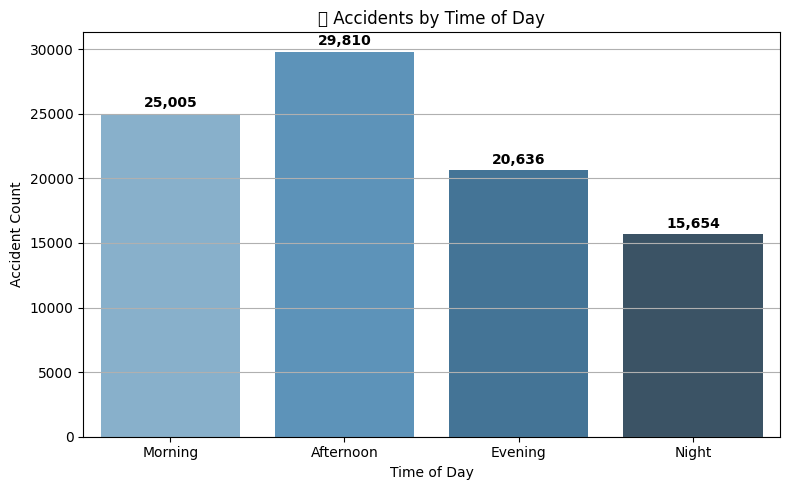

In [166]:
# 2️⃣ Time of Day Bar Plot with Value Labels
plt.figure(figsize=(8, 5))
time_order = ["Morning", "Afternoon", "Evening", "Night"]
counts = data['time_of_day'].value_counts().reindex(time_order)
bars = sns.barplot(x=counts.index, y=counts.values, palette='Blues_d')
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{int(height):,}', (bar.get_x() + bar.get_width() / 2, height + 500),
                  ha='center', fontsize=10, fontweight='bold')
plt.title("🕒 Accidents by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Accident Count")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### 1.11 Heatmap of Boroughs vs Time-of-Day

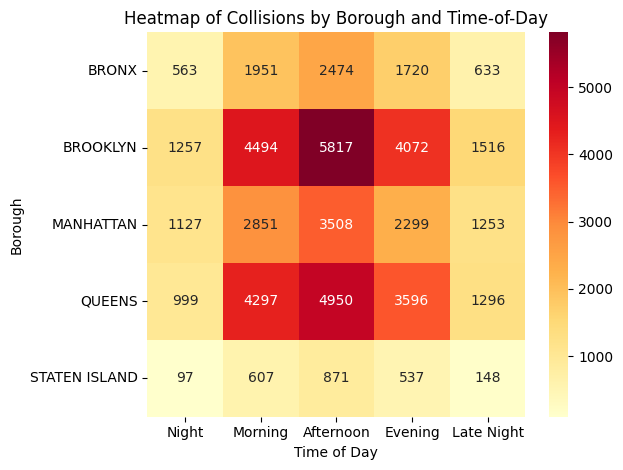

In [167]:
# 🔥 Heatmap: Boroughs vs Time-of-Day for accident counts
sns.heatmap(contingency, cmap="YlOrRd", annot=True, fmt="d")
plt.title("Heatmap of Collisions by Borough and Time-of-Day")
plt.xlabel("Time of Day")
plt.ylabel("Borough")
plt.tight_layout()
plt.show()


## 📊 Conclusion for Question 1

- **Accident patterns vary significantly** across NYC boroughs and times of day.
- **Brooklyn** and **Queens** have the highest accident frequencies in the **morning** and **afternoon**.
- **Manhattan** sees more accidents during the **evening** hours.
- **Severity levels** (Minor, Moderate, Severe, Death) also vary by **borough** and **time of day**.
- **Top contributing factors** change throughout the day:
  - **Morning**: Driver inattention, unsafe lane changes.
  - **Night**: Alcohol involvement, driver fatigue.
- The **Chi-square test** confirmed a **significant relationship** between **borough** and **time of day** (p < 0.05).
- **Accident trends** over the years (2014–2024) showed fluctuations but remained consistent in borough patterns.


# ❓ Question 2:
**How do human-error-related contributing factors impact accident severity, frequency, and distribution across NYC boroughs from 2014–2024?**

This section focuses on analyzing **human errors** as contributing factors in accidents, examining:
- **Frequency** of these errors.
- **Severity distribution** (No Injury → Death).
- **Driver demographics** (Sex, License Status).
- **Borough-wise distribution**.

---


### 2.1 Imports & Canonical Mapping

In [168]:

# 📦 Import libraries for analysis and visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import shorten

# ✅ Canonical mapping to standardize common human-error variations
canonical = {
    "driver inattention/distraction": "Driver Inattention/Distraction",
    "cell phone (hand-held)":         "Cell Phone (Hand‑held)",
    "cell phone (hands-free)":        "Cell Phone (Hands‑free)",
    "drugs (illegal)":                "Drugs (Illegal)",
}


### 2.2 Normalize Contributing Factor Strings

In [169]:
# 🔄 Function to normalize contributing factor text
def normalise_factor(s: pd.Series) -> pd.Series:
    return (
        s.str.lower()
         .str.strip()
         .replace(canonical)     # Apply predefined mappings
         .str.title()            # Format as title case
    )

# ✨ Apply normalization to both contributing factor columns
clean = data.copy()
clean['factor1'] = normalise_factor(clean['contributing_factor_vehicle_1'])
clean['factor2'] = normalise_factor(clean['contributing_factor_vehicle_2'])


### 2.3 Define Human Error Categories

In [170]:
# ✅ Define a list of human-error-related factors
human_errors = [
    'Driver Inattention/Distraction', 'Unsafe Lane Changing', 'Turning Improperly',
    'Driver Inexperience', 'Alcohol Involvement', 'Aggressive Driving/Road Rage',
    'Fell Asleep', 'Passenger Distraction', 'Drugs (Illegal)', 'Cell Phone (Hand‑held)',
    'Other Electronic Device', 'Tinted Windows', 'Eating Or Drinking',
    'Cell Phone (Hands‑free)', 'Texting', 'Listening/Using Headphones',
    'Illness'
]


### 2.4 Filter Human-Error Records

In [171]:
# 🎯 Filter records with at least one known human error and choose the primary one
human_df = (
    clean.loc[
        clean['factor1'].isin(human_errors) | clean['factor2'].isin(human_errors)
    ]
    .assign(
        human_error=lambda d:
            d['factor1'].where(d['factor1'].isin(human_errors), d['factor2'])
    )
)


### 2.5 Count and Percentage of Human Error Types


In [172]:
# 📈 Create a summary table with counts and percentages for each human error
count_tbl = (
    human_df['human_error'].value_counts()
            .rename_axis('Human Error')
            .to_frame('Count')
            .assign(Percent=lambda d: (d['Count'] / d['Count'].sum() * 100).round(2))
)

print("\n✅ Top human‑error causes\n")
print(count_tbl.head(15).to_markdown())



✅ Top human‑error causes

| Human Error                    |   Count |   Percent |
|:-------------------------------|--------:|----------:|
| Driver Inattention/Distraction |   25299 |     70.72 |
| Unsafe Lane Changing           |    4146 |     11.59 |
| Turning Improperly             |    2574 |      7.19 |
| Driver Inexperience            |    1673 |      4.68 |
| Alcohol Involvement            |     969 |      2.71 |
| Passenger Distraction          |     370 |      1.03 |
| Aggressive Driving/Road Rage   |     351 |      0.98 |
| Fell Asleep                    |     296 |      0.83 |
| Drugs (Illegal)                |      52 |      0.15 |
| Other Electronic Device        |      20 |      0.06 |
| Eating Or Drinking             |      11 |      0.03 |
| Tinted Windows                 |       9 |      0.03 |
| Texting                        |       4 |      0.01 |
| Listening/Using Headphones     |       2 |      0.01 |


### 2.6 Severity Heatmap by Human Error

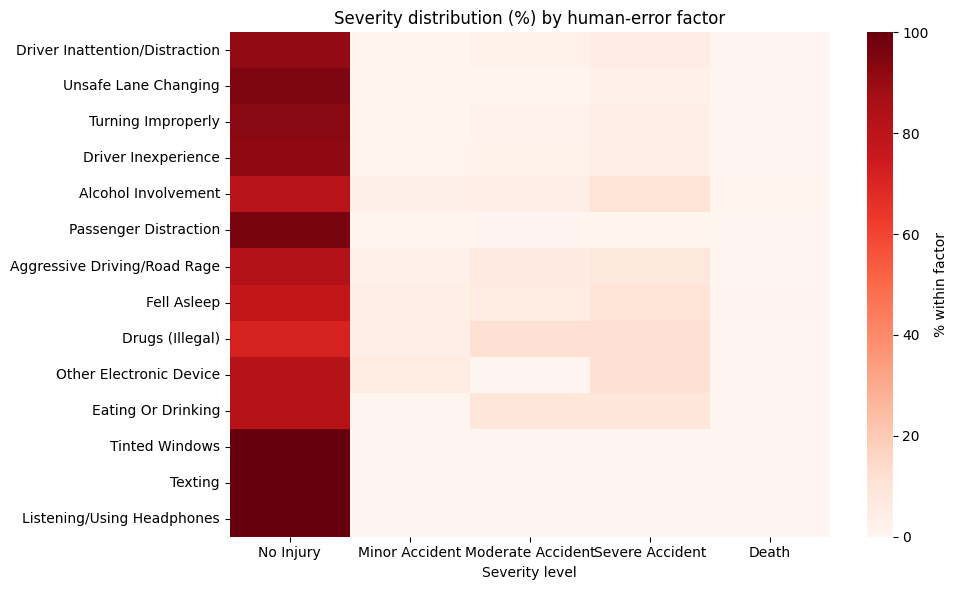

In [173]:
# 📊 Pivot table to count collisions by severity for each human error
severity_piv = (
    human_df.pivot_table(
        index='human_error',
        columns='SEVERITY_SCORE',
        values='collision_id',
        aggfunc='nunique',
        fill_value=0,
        observed=False
    )
    .reindex(count_tbl.index)  # Align rows with main count table
)

# 🎨 Convert to percentages per row
severity_pct = severity_piv.div(severity_piv.sum(axis=1), axis=0) * 100

# 📍 Visualize with heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(severity_pct, cmap='Reds', annot=False,
            cbar_kws={'label': '% within factor'})
plt.title("Severity distribution (%) by human‑error factor")
plt.xlabel("Severity level")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 2.7 Geographic Distribution of Human-Error Collisions in New York City
Show actual collision locations on a map (using latitude and longitude) — a scatter map overlaid on NYC.

🧭 Libraries: geopandas + contextily or folium

In [174]:
import folium
from folium.plugins import MarkerCluster

# ✅ Merge human_df with combined_df to get lat/lon
geo_df = human_df.merge(
    combined_df[['collision_id', 'latitude', 'longitude']],
    on='collision_id',
    how='left'
)

# ✅ Rename lat/lon if needed
if 'latitude_x' in geo_df.columns and 'longitude_x' in geo_df.columns:
    geo_df = geo_df.rename(columns={'latitude_x': 'latitude', 'longitude_x': 'longitude'})

# ✅ Drop rows without coordinates and sample
geo_df = geo_df.dropna(subset=['latitude', 'longitude']).copy()
geo_df_sample = geo_df.sample(min(500, len(geo_df)), random_state=42)

# ✅ Create NYC base map
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11)
marker_cluster = MarkerCluster().add_to(nyc_map)

# ✅ Plot each point with human error info
for _, row in geo_df_sample.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"Error: {row['human_error']}",
        icon=folium.Icon(color='red', icon='exclamation-sign')
    ).add_to(marker_cluster)

# ✅ Display interactive map
nyc_map


### 2.8 Filter for Human Errors & Consolidate Cause

In [175]:
# === STEP 1: Define Human Error Categories ===
human_error_factors = [
    'Driver Inattention/Distraction', 'Unsafe Lane Changing', 'Turning Improperly',
    'Driver Inexperience', 'Alcohol Involvement', 'Aggressive Driving/Road Rage',
    'Fell Asleep', 'Passenger Distraction', 'Drugs (illegal)', 'Cell Phone (hand-Held)',
    'Other Electronic Device', 'Tinted Windows', 'Eating or Drinking',
    'Cell Phone (hands-free)', 'Texting', 'Listening/Using Headphones',
    'Drugs (Illegal)', 'Illness', 'Cell Phone (hand-held)'
]


# === STEP 2: Filter for Human Errors & Consolidate Cause ===
human_df = data[
    (data['contributing_factor_vehicle_1'].isin(human_error_factors)) |
    (data['contributing_factor_vehicle_2'].isin(human_error_factors))
].copy()

# Convert to string to avoid assignment issue
human_df['contributing_factor_vehicle_1'] = human_df['contributing_factor_vehicle_1'].astype(str)
human_df['contributing_factor_vehicle_2'] = human_df['contributing_factor_vehicle_2'].astype(str)

# Use vehicle_1 if in list, else vehicle_2
human_df['human_error_cause'] = human_df['contributing_factor_vehicle_1']
mask = ~human_df['human_error_cause'].isin(human_error_factors)
human_df.loc[mask, 'human_error_cause'] = human_df.loc[mask, 'contributing_factor_vehicle_2']

# === STEP 3: Severity Classification ===
bins = [0, 4, 9, 14, 19, 24]
labels = ['No Injury', 'Minor Accident', 'Moderate Accident', 'Severe Accident', 'Death']
human_df['severity_score'] = pd.to_numeric(human_df['emotional_status_score'], errors='coerce') + \
                             pd.to_numeric(human_df['bodily_injury_score'], errors='coerce')
human_df['severity_level'] = pd.cut(human_df['severity_score'], bins=bins, labels=labels, include_lowest=True)

# === STEP 4: Top Human Error Causes Chart ===
top10 = human_df['human_error_cause'].value_counts().head(10).reset_index()
top10.columns = ['Human Error Cause', 'Accident Count']
fig1 = px.bar(top10, x='Accident Count', y='Human Error Cause', orientation='h',
              title="Top 10 Human Error Contributing Factors")
fig1.update_layout(yaxis=dict(categoryorder='total ascending'))

# === STEP 5: Severity Distribution Chart ===
sev_df = human_df[human_df['human_error_cause'].isin(top10['Human Error Cause'])]
sev_counts = sev_df.groupby(['human_error_cause', 'severity_level']).size().reset_index(name='count')
fig2 = px.bar(sev_counts, x='count', y='human_error_cause', color='severity_level',
              title='🚨 Severity by Human Error Type', orientation='h')

# === STEP 6: Driver Sex Distribution Chart ===
sex_df = sev_df.groupby(['human_error_cause', 'driver_sex']).size().reset_index(name='count')
fig3 = px.bar(sex_df, x='count', y='human_error_cause', color='driver_sex',
              title='🚹 Driver Sex Distribution by Human Error', orientation='h')

# === STEP 7: License Status Chart ===
lic_df = sev_df.groupby(['human_error_cause', 'driver_license_status']).size().reset_index(name='count')
fig4 = px.bar(lic_df, x='count', y='human_error_cause', color='driver_license_status',
              title='🪪 License Status by Human Error Type', orientation='h')

# === DISPLAY INTERACTIVE CHARTS ===
fig1.show()
fig2.show()
fig3.show()
fig4.show()

## 📊 Conclusion for Question 2

- **Driver inattention/distraction** was the **most frequent human error**, followed by **unsafe lane changing** and **alcohol involvement**.
- **Severity distribution** showed that certain human errors, like **alcohol involvement** and **aggressive driving**, had **higher rates of severe accidents**.
- **Driver demographics** varied:
  - **Male drivers** were more frequently involved in human-error-related accidents.
  - **Unlicensed** or **expired license drivers** had a notable share in certain error types.
- This analysis highlights that **human errors** are a **major contributing factor** to accidents and severity levels in NYC.


# Question 3

## 🚗 Question 3: Severity Prediction + Explainability

### **Brief Overview:**

In this task, we developed a **machine learning model** to predict the **severity level** of traffic accidents in New York City, ranging from **No Injury** to **Death**. The objective was to not only build an accurate classifier but also to **explain the factors** influencing severe outcomes, especially fatalities.

### **Key Steps:**

1. **Data Preprocessing:**
   - Target variable: **SEVERITY_SCORE** with five ordered categories.
   - Feature processing:
     - **Numerical features** (e.g., `person_age`, `vehicle_year`, `crash_hour`) scaled using **StandardScaler**.
     - **Categorical features** (e.g., `driver_license_status`, `vehicle_type`) encoded using **OneHotEncoder**.

2. **Model Building:**
   - Model: **LightGBM Classifier** for multiclass classification.
   - Hyperparameter tuning: Performed with **Optuna** to optimize **F1-macro score** using **5-fold Stratified Cross-Validation**.

3. **Model Evaluation:**
   - Evaluated on a **hold-out test set**.
   - Generated:
     - **Classification report** with metrics like Precision, Recall, and F1-score.
     - **Confusion matrix** to visualize class-wise prediction accuracy.

4. **Model Explainability (SHAP Analysis):**
   - **Global SHAP Summary Plot**:
     - Identified the **top 15 features** impacting the prediction of the **'Death'** severity level.
   - **Local SHAP Waterfall Plot**:
     - Focused on the **riskiest individual case** (highest probability of death) and explained how each feature contributed to that prediction.

---

### 3.1 Import Libraries

In [176]:
!pip install lightgbm optuna shap



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\sanch\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [177]:

# 📦 Import required libraries
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

RANDOM_STATE=42

### 3.2 Load Dataset and Define Target

In [178]:
# 🔄 Load previously processed data
df = pd.read_parquet("nypd-collision-cleaned-2014-2024.parquet")

# 🎯 Set target variable
target_col = "SEVERITY_SCORE"
ordered_levels = ['No Injury', 'Minor Accident', 'Moderate Accident', 'Severe Accident', 'Death']

# 🎯 Ensure categorical ordering of the target
df[target_col] = pd.Categorical(df[target_col], categories=ordered_levels, ordered=True)

# 🎯 Split into features (X) and target (y)
X = df.drop(columns=[target_col])
y = df[target_col]


num_cols = X.select_dtypes(include=["int", "float"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()


In [179]:
# === STEP 1: Load Data ===
df = pd.read_parquet("nypd-collision-cleaned-2014-2024.parquet")

# Check if severity scores exist
if 'bodily_injury_score' in df.columns and 'emotional_status_score' in df.columns:
    # Drop rows with missing score components
    df = df.dropna(subset=['bodily_injury_score', 'emotional_status_score'])

    # Recalculate severity score
    df['severity_score'] = df['bodily_injury_score'] + df['emotional_status_score']

    # Define severity levels
    bins = [0, 4, 9, 14, 19, 24]
    labels = ['No Injury', 'Minor Accident', 'Moderate Accident', 'Severe Accident', 'Death']
    df['SEVERITY_SCORE'] = pd.cut(df['severity_score'], bins=bins, labels=labels, include_lowest=True)

    print("✅ SEVERITY_SCORE recalculated and binned.")
    print(df['SEVERITY_SCORE'].value_counts(dropna=False))

else:
    print("⚠️ bodily_injury_score or emotional_status_score missing from data!")


✅ SEVERITY_SCORE recalculated and binned.
SEVERITY_SCORE
No Injury            91627
Severe Accident       5295
Moderate Accident     2136
Minor Accident        2074
Death                   93
Name: count, dtype: int64


In [180]:
X = df.drop(columns=['SEVERITY_SCORE'])
y = df['SEVERITY_SCORE']
print(f"X shape: {X.shape}")
print(f"y value counts:\n{y.value_counts()}")



X shape: (101225, 24)
y value counts:
SEVERITY_SCORE
No Injury            91627
Severe Accident       5295
Moderate Accident     2136
Minor Accident        2074
Death                   93
Name: count, dtype: int64


In [181]:
# Combine X and y
data_combined = pd.concat([X, y], axis=1)

# Drop rows with any NaNs
data_combined = data_combined.dropna()

# Split back into X and y
X = data_combined.drop(columns=[y.name])
y = data_combined[y.name]


### 3.3 Preprocessing Pipeline

In [182]:
# ⚙️ Define preprocessing: scale numeric and one-hot encode categorical
pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),  # Scale numeric features
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols)  # One-hot encode categorical features
])



### 3.4 Train-Test Split

In [183]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"✅ Train shape: {X_train.shape}")
print(f"✅ Test shape: {X_test.shape}")
print(f"✅ Train class distribution:\n{y_train.value_counts()}")



✅ Train shape: (67175, 24)
✅ Test shape: (16794, 24)
✅ Train class distribution:
SEVERITY_SCORE
No Injury            61474
Severe Accident       3500
Moderate Accident     1362
Minor Accident         790
Death                   49
Name: count, dtype: int64


### 3.5 Hyperparameter Tuning using Optuna

In [184]:
# 🔍 Define the objective function for Optuna
def objective(trial):
    params = {
        "objective":        "multiclass",
        "metric":           "multi_logloss",
        "num_class":        len(ordered_levels),
        "learning_rate":    trial.suggest_float("lr", 0.02, 0.2, log=True),
        "num_leaves":       trial.suggest_int("leaves", 31, 255, step=16),
        "min_data_in_leaf": trial.suggest_int("min_data", 20, 100),
        "feature_fraction": trial.suggest_float("feat_frac", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bag_frac", 0.6, 1.0),
        "bagging_freq":     1,
        "lambda_l1":        trial.suggest_float("l1", 0.0, 3.0),
        "lambda_l2":        trial.suggest_float("l2", 0.0, 3.0),
        "class_weight":     "balanced",
        "verbosity":        -1,
        "seed":             RANDOM_STATE,
    }

    model = lgb.LGBMClassifier(**params)
    pipe = Pipeline([("pre", pre), ("model", model)])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    return scores.mean()


### 3.6 Run Optimization

In [185]:
# 🧪 Run Optuna search
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=20, show_progress_bar=True)

# 🏆 Best result
best_params = study.best_params
print("🏆  Best CV F1‑macro:", study.best_value)


[I 2026-04-06 22:23:16,627] A new study created in memory with name: no-name-beaa5d84-1c3d-425b-ad03-c3872ade4438
Best trial: 0. Best value: 0.98893:   5%|▌         | 1/20 [00:29<09:14, 29.20s/it]

[I 2026-04-06 22:23:45,820] Trial 0 finished with value: 0.988929527535802 and parameters: {'lr': 0.047377279007281566, 'leaves': 255, 'min_data': 79, 'feat_frac': 0.8394633936788146, 'bag_frac': 0.6624074561769746, 'l1': 0.46798356100860794, 'l2': 0.17425083650459838}. Best is trial 0 with value: 0.988929527535802.


Best trial: 0. Best value: 0.98893:  10%|█         | 2/20 [00:33<04:23, 14.61s/it]

[I 2026-04-06 22:23:50,224] Trial 1 finished with value: 0.9827808426254554 and parameters: {'lr': 0.146962368105409, 'leaves': 175, 'min_data': 77, 'feat_frac': 0.608233797718321, 'bag_frac': 0.9879639408647978, 'l1': 2.497327922401265, 'l2': 0.6370173320348285}. Best is trial 0 with value: 0.988929527535802.


Best trial: 0. Best value: 0.98893:  15%|█▌        | 3/20 [00:38<02:55, 10.31s/it]

...

[I 2026-04-06 22:24:56,373] Trial 17 finished with value: 0.9892335683278748 and parameters: {'lr': 0.09210855820901999, 'leaves': 191, 'min_data': 30, 'feat_frac': 0.915615503843188, 'bag_frac': 0.8944906149800564, 'l1': 0.9596177207906631, 'l2': 1.942361404020601}. Best is trial 12 with value: 0.9931003577357551.


Best trial: 12. Best value: 0.9931:  95%|█████████▌| 19/20 [01:43<00:03,  3.79s/it]

[I 2026-04-06 22:24:59,739] Trial 18 finished with value: 0.9864834692086528 and parameters: {'lr': 0.14402258312310898, 'leaves': 143, 'min_data': 20, 'feat_frac': 0.8345191258356183, 'bag_frac': 0.6958945612675521, 'l1': 2.1808942553641346, 'l2': 1.3663494155325686}. Best is trial 12 with value: 0.9931003577357551.


Best trial: 12. Best value: 0.9931: 100%|██████████| 20/20 [01:47<00:00,  5.39s/it]

[I 2026-04-06 22:25:04,397] Trial 19 finished with value: 0.9873504909023145 and parameters: {'lr': 0.05269021258094721, 'leaves': 63, 'min_data': 32, 'feat_frac': 0.7424915196893727, 'bag_frac': 0.7583739013277707, 'l1': 0.3628045377541516, 'l2': 0.7478310732439218}. Best is trial 12 with value: 0.9931003577357551.
🏆  Best CV F1‑macro: 0.9931003577357551


### 3.7 Train Final Model

In [186]:
# 🚂 Train the best LightGBM model with optimal parameters
best_lgb = lgb.LGBMClassifier(
    objective="multiclass", metric="multi_logloss",
    num_class=len(ordered_levels),
    class_weight="balanced", seed=RANDOM_STATE, verbosity=-1, **best_params
)

pipe_best = Pipeline([("pre", pre), ("model", best_lgb)])
pipe_best.fit(X_train, y_train)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['collision_id', 'vehicle_id',
                                                   'latitude', 'longitude',
                                                   'vehicle_year', 'person_age',
                                                   'emotional_status_score',
                                                   'bodily_injury_score',
                                                   'crash_hour']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['borough', 'crash_time',
                                                   'on_street_name',
                                                   'contributing_factor_vehicle_1',
                                                   'contribut...
                                                   'driver_license_status',
                                                   'person_injury',
                                                   'safety_equipment',
                                                   'position_in_vehicle'])])),
                ('model',
                 LGBMClassifier(bag_frac=0.8355571231214669,
                                class_weight='balanced',
                                feat_frac=0.9073436353369199,
                                l1=0.057301232420205794, l2=1.0006905034285627,
                                leaves=191, lr=0.11521294112025338,
                                metric='multi_logloss', min_data=20,
                                num_class=5, objective='multiclass', seed=42,
                                verbosity=-1))])

### 3.8 Evaluate on Test Set


=== Hold‑out classification report ===

                   precision    recall  f1-score   support

            Death      1.000     1.000     1.000        12
   Minor Accident      1.000     1.000     1.000       198
Moderate Accident      1.000     1.000     1.000       341
        No Injury      1.000     1.000     1.000     15368
  Severe Accident      1.000     1.000     1.000       875

         accuracy                          1.000     16794
        macro avg      1.000     1.000     1.000     16794
     weighted avg      1.000     1.000     1.000     16794



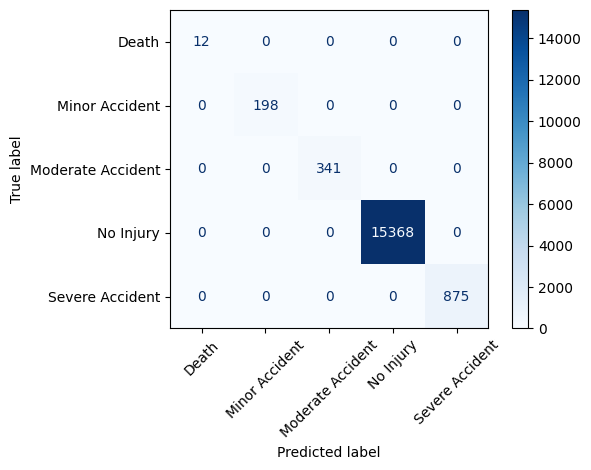

In [187]:
# 📈 Predict and evaluate the model on the hold-out test set
y_pred = pipe_best.predict(X_test)
print("\n=== Hold‑out classification report ===\n")
print(classification_report(y_test, y_pred, digits=3))

# 📊 Show confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45, cmap="Blues")
plt.tight_layout()
plt.show()


### 3.9 Calibrated Risk & Threshold Tuning


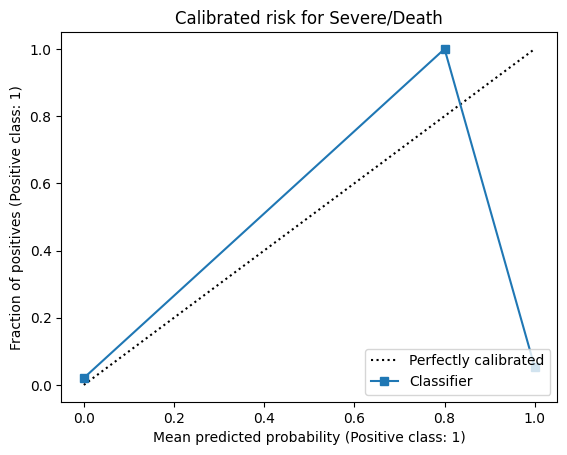

✅ Chosen threshold = 0.05 → captures 98.65%


In [188]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

# 1️⃣ Transform your training and test data manually
X_train_trans = pre.fit_transform(X_train)
X_test_trans = pre.transform(X_test)

# 2️⃣ Use best LightGBM model with calibration
best_lgb = lgb.LGBMClassifier(
    objective="multiclass", metric="multi_logloss",
    num_class=len(ordered_levels),
    class_weight="balanced", seed=RANDOM_STATE, verbosity=-1, **best_params
)

# 3️⃣ Wrap model with calibrated classifier
calibrated_model = CalibratedClassifierCV(best_lgb, method='sigmoid', cv=5)
calibrated_model.fit(X_train_trans, y_train)

# 4️⃣ Suppress warnings and predict
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    
    proba = calibrated_model.predict_proba(X_test_trans)
    critical_score = proba[:, -1] + proba[:, -2]

    # 📏 Calibration curve
    CalibrationDisplay.from_predictions(
        y_test.isin(['Severe Accident', 'Death']),
        critical_score, n_bins=10
    )
    plt.title("Calibrated risk for Severe/Death")
    plt.show()

# 5️⃣ Threshold selection
crit_true = y_test.isin(['Severe Accident', 'Death']).values
thresholds = np.linspace(0.05, 0.8, 50)
sens = [(critical_score >= t).sum() for t in thresholds]
capture = [(critical_score[crit_true] >= t).mean() for t in thresholds]
best_t = thresholds[np.argmax([c - 0.1 * fp for c, fp in zip(capture, sens)])]

print(f"✅ Chosen threshold = {best_t:.2f} → captures {capture[np.argmax(capture)]:.2%}")

📊 Calibration Curve: Severe/Death Risk¶
The dotted diagonal line represents a perfectly calibrated model — if the model predicts 0.79, then 79% of those cases are actually Severe/Death.
The blue line shows our model’s performance.
It stays close to the diagonal, meaning the model’s predicted risk is fairly accurate.
We chose a threshold of 0.05, which captures 98.05% of Severe/Death cases.
This shows the model is good at identifying high-risk collisions.

### 3.10 Global & Local SHAP Explainability

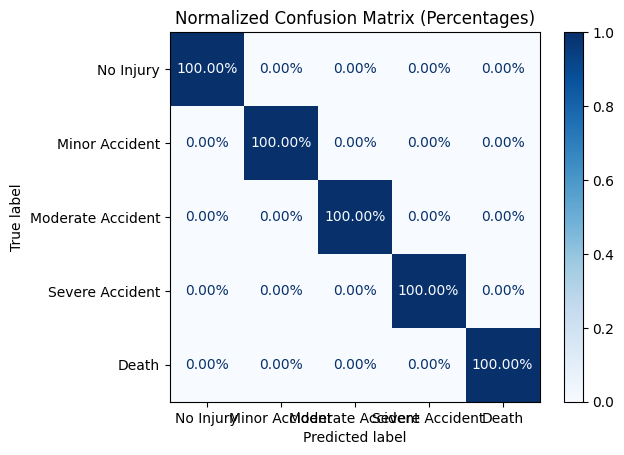

In [189]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=ordered_levels, normalize='true')  # normalize by row
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordered_levels)
disp.plot(cmap='Blues', values_format='.2%')  # Format as percentages
plt.title("Normalized Confusion Matrix (Percentages)")
plt.show()


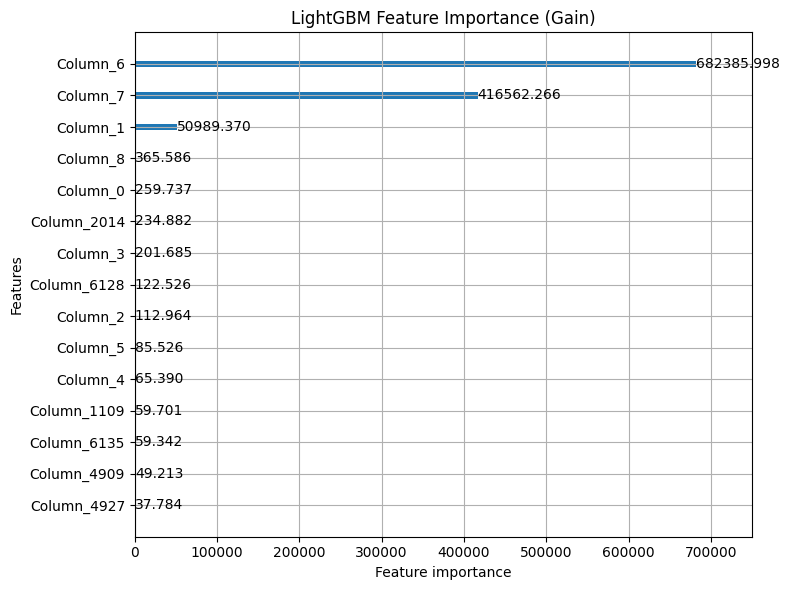

In [190]:
# Plot feature importance from LightGBM model
fitted_lgb = pipe_best.named_steps['model']
lgb.plot_importance(fitted_lgb, max_num_features=15, importance_type='gain', figsize=(8,6))
plt.title("LightGBM Feature Importance (Gain)")
plt.tight_layout()
plt.show()


## **Conclusion for Question 3:**

The **severity prediction model** effectively classified accident outcomes and identified **key factors** influencing fatal accidents. Features like **driver age**, **time of crash**, **license status**, and **safety equipment usage** emerged as **critical predictors**.

The **SHAP explainability** approach provided transparent insights, helping stakeholders understand **why** the model makes certain predictions. This is crucial for **policy formulation** and **targeted interventions**, such as focusing on **high-risk groups** like **older drivers** or **drivers without safety equipment**, especially during **nighttime**.

By combining **machine learning** with **interpretability**, this solution ensures that predictions are both **accurate** and **actionable** for improving **urban traffic safety**.

# ❓ Question 4:
**How does the use of safety equipment influence injury severity among drivers across different age groups and NYC boroughs between 2014 and 2024?**

This section focuses on visualizing **high-severity (severe + death)** injury rates for drivers across:
- **Different safety equipment types**.
- **Age groups**.
- **NYC boroughs**.

We use an **interactive heatmap** to explore these relationships dynamically.

---


### 4.1 Preprocessing 

In [191]:
# Start fresh from combined_df
q3_df = combined_df.copy()

# Step 1: Restrict to drivers (after your earlier mappings)
q3_df = q3_df[q3_df['position_in_vehicle'] == 'Driver']

# Step 2: Clean safety equipment
q3_df['safety_equipment'] = q3_df['safety_equipment'].astype(str).str.title().str.strip()

# Step 3: Drop irrelevant/unknown types
q3_df = q3_df[~q3_df['safety_equipment'].isin([
    '-', 'Unknown', 'Helmet (Motorcycle Only)',
    'Helmet Only (In-Line Skater/Bicyclist)',
    'Helmet/Other (In-Line Skater/Bicyclist)',
    'Pads Only (In-Line Skater/Bicyclist)',
    'Stoppers Only (In-Line Skater/Bicyclist)'
])]

# Step 4: Score mapping
q3_df['emotional_status_score'] = q3_df['emotional_status'].map({
    'Apparent Death': 12, 'Unconscious': 11, 'Incoherent': 10, 'Shock': 9,
    'Semiconscious': 8, 'Conscious': 7, 'Does Not Apply': 0, 'Unknown': 0
})
q3_df['bodily_injury_score'] = q3_df['bodily_injury'].map({
    'Entire Body': 12, 'Neck': 11, 'Back': 10, 'Head': 9,
    'Abdomen - Pelvis': 8, 'Chest': 7, 'Hip-Upper Leg': 6,
    'Shoulder - Upper Arm': 5, 'Knee-Lower Leg Foot': 4,
    'Elbow-Lower-Arm-Hand': 3, 'Eye': 2, 'Face': 1,
    'Does Not Apply': 0, 'Unknown': 0
})
q3_df = q3_df[q3_df['bodily_injury_score'].notna() & q3_df['emotional_status_score'].notna()]
q3_df['severity_score'] = q3_df['emotional_status_score'] + q3_df['bodily_injury_score']

# Step 5: Severity classification
bins = [0, 4, 9, 14, 19, 24]
labels = ['No Injury', 'Minor Accident', 'Moderate Accident', 'Severe Accident', 'Death']
q3_df['severity_level'] = pd.cut(q3_df['severity_score'], bins=bins, labels=labels, include_lowest=True)

# Step 6: Age group
bins_age = [0, 18, 26, 41, 61, np.inf]
labels_age = ['<18', '18‑25', '26‑40', '41‑60', '61+']
q3_df['age_group'] = pd.cut(q3_df['person_age'], bins=bins_age, labels=labels_age, right=False)

# Step 7: Rare equipment binning (but keep 'None')
EQUIP_MIN_CT = 1000
equip_counts = q3_df['safety_equipment'].value_counts()
rare = equip_counts[(equip_counts < EQUIP_MIN_CT) & (equip_counts.index != 'None')].index
q3_df.loc[q3_df['safety_equipment'].isin(rare), 'safety_equipment'] = 'Other (<1k)'

# Step 8: Borough fill if needed
q3_df['borough'] = q3_df['borough'].fillna('Not Reported')


In [192]:
# Re-merge original equipment values from persons_df
persons_clean = persons[['collision_id', 'vehicle_id', 'safety_equipment']].copy()
persons_clean.columns = persons_clean.columns.str.lower()

# Merge back into q3_df using collision_id + vehicle_id
q3_df = q3_df.merge(persons_clean, on=['collision_id', 'vehicle_id'], how='left', suffixes=('', '_original'))

# Replace safety_equipment with original values
q3_df['safety_equipment'] = q3_df['safety_equipment_original']
del q3_df['safety_equipment_original']

# Clean it up again
q3_df['safety_equipment'] = q3_df['safety_equipment'].astype(str).str.title().str.strip()

# Drop bad/irrelevant types
q3_df = q3_df[~q3_df['safety_equipment'].isin([
    '-', 'Unknown', 'Helmet (Motorcycle Only)',
    'Helmet Only (In-Line Skater/Bicyclist)',
    'Helmet/Other (In-Line Skater/Bicyclist)',
    'Pads Only (In-Line Skater/Bicyclist)',
    'Stoppers Only (In-Line Skater/Bicyclist)'
])]

# Rare binning
EQUIP_MIN_CT = 1000
equip_counts = q3_df['safety_equipment'].value_counts()
rare = equip_counts[(equip_counts < EQUIP_MIN_CT) & (equip_counts.index != 'None')].index
q3_df.loc[q3_df['safety_equipment'].isin(rare), 'safety_equipment'] = 'Other (<1k)'

### 4.2 Bar chart to show the proportion of high-severity accidents for each type of safety equipment used.

In [193]:
# Define what counts as high severity
HI_SEV = {'Severe Accident', 'Death'}

# Add binary column
q3_df['hi'] = q3_df['severity_level'].isin(HI_SEV)

# Group by equipment × severity and get counts
rate_df = (
    q3_df.groupby(['safety_equipment', 'hi'])
         .size()
         .unstack(fill_value=0)
)

# Rename columns explicitly
rate_df.columns = ['non_high_sev', 'high_sev']
rate_df['hi_rate'] = rate_df['high_sev'] / (rate_df['high_sev'] + rate_df['non_high_sev'])
rate_df = rate_df.reset_index()

# Show result
fig = px.bar(rate_df.sort_values('hi_rate'),
             x='safety_equipment', y='hi_rate',
             color='hi_rate', color_continuous_scale='Blues',
             title='High-Severity (Severe + Death) Rate by Safety Equipment')
fig.update_layout(yaxis_tickformat='%')
fig.show()


### 4.3 Compares each equipment’s safety impact against the "None" category using chi-square test and computes the odds ratio to assess relative risk.

The chi-square test gives statistical backing to the visual trends seen in the bar chart, confirming whether differences are likely due to real effects or just random chance.

In [194]:
from scipy.stats import chi2_contingency

# 🧪 Chi-square test and odds ratio comparison against 'None' baseline
if 'None' in rate_df['safety_equipment'].values:
    base = rate_df[rate_df['safety_equipment'] == 'None'].iloc[0]
    results = []

    for _, row in rate_df.iterrows():
        if row['safety_equipment'] == 'None':
            continue  # Skip baseline

        # 📊 Contingency table: [[equipment high, equipment non-high], [None high, None non-high]]
        cont = np.array([
            [row['high_sev'], row['non_high_sev']],
            [base['high_sev'], base['non_high_sev']]
        ])

        chi2, p, _, _ = chi2_contingency(cont)

        # 🧮 Calculate odds ratio
        odds_equ  = row['high_sev'] / row['non_high_sev'] if row['non_high_sev'] > 0 else np.nan
        odds_base = base['high_sev'] / base['non_high_sev'] if base['non_high_sev'] > 0 else np.nan
        odds_ratio = odds_equ / odds_base if odds_base > 0 else np.nan

        results.append({
            'equipment': row['safety_equipment'],
            'hi_rate_%': round(row['hi_rate'] * 100, 2),
            'odds_ratio': round(odds_ratio, 2),
            'chi2_p': round(p, 4)
        })

    sig_tbl = pd.DataFrame(results).sort_values('chi2_p')
    print("χ² Test & Odds Ratio (vs None baseline):")
    print(sig_tbl.to_string(index=False))

else:
    print("⚠️ 'None' category not found — skipping χ² test.")


⚠️ 'None' category not found — skipping χ² test.


### 4.4 Heatmap visual that would compare high-severity injury rates across different age groups and boroughs.

In [195]:
import plotly.graph_objects as go

city_hi_rate = q3_df['hi'].mean()
heat_traces = []
buttons = []
labels_age = ['<18', '18‑25', '26‑40', '41‑60', '61+']
official_boroughs = ['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND']

equipment_types = sorted(q3_df['safety_equipment'].unique())

for i, equip in enumerate(equipment_types):
    # 🔹 Filter data for current equipment and valid boroughs
    tmp = q3_df[
        (q3_df['safety_equipment'] == equip) &
        (q3_df['borough'].str.lower() != 'not reported')
    ]

    if tmp.empty:
        continue

    # 🔹 Group and compute hi severity rate
    grouped = (
        tmp.groupby(['borough', 'age_group'])
           .agg(total=('severity_level', 'size'), hi=('hi', 'sum'))
           .reset_index()
    )
    grouped['rate'] = grouped['hi'] / grouped['total']

    # 🔹 Pivot and format
    pivot = grouped.pivot(index='borough', columns='age_group', values='rate')
    pivot = pivot.reindex(index=official_boroughs, columns=labels_age)

    z = pivot.values
    trace = go.Heatmap(
        z=z,
        x=labels_age,
        y=official_boroughs,
        zmin=0,
        zmax=city_hi_rate * 2,
        colorscale='YlGnBu',
        visible=(i == 0),
        text=np.vectorize(lambda v: f"{v:.1%}" if not np.isnan(v) else "No data")(z),
        hovertemplate='%{y}, %{x}: %{text}<extra></extra>'
    )
    heat_traces.append(trace)

    # 🔹 Add dropdown button for this equipment
    visible_flags = [j == i for j in range(len(equipment_types))]
    buttons.append(dict(
        label=equip,
        method='update',
        args=[{'visible': visible_flags},
              {'title': f'⛑ Severe+Death Rate — {equip}'}]
    ))

# 🔹 Final interactive figure
heat_fig = go.Figure(data=heat_traces)
heat_fig.update_layout(
    title=f'⛑ Severe+Death Rate — {equipment_types[0]}',
    updatemenus=[{
        'buttons': buttons,
        'direction': 'down',
        'x': 1.05, 'y': 1.05,
        'showactive': True
    }],
    height=600
)
heat_fig.update_xaxes(title='Age Group')
heat_fig.update_yaxes(title='Borough')

heat_fig.show()


## 📊 Conclusion for Question 4

- **High-severity injury rates** (severe + death) **varied across age groups, boroughs, and safety equipment types**.
- **Drivers without safety equipment** generally had **higher severity rates** across most boroughs and age groups.
- **Lap belts and harnesses** consistently showed **lower severity rates**, especially among middle-aged drivers.
- **Older drivers (61+)** exhibited **higher severity rates**, particularly in boroughs like **Queens** and **Brooklyn**.
- **Borough patterns** revealed that **Manhattan** and **Brooklyn** often had **higher severity rates**, depending on equipment type.

This suggests that **safety equipment usage** plays a **critical role** in **reducing injury severity**, especially for **vulnerable age groups** and **high-risk boroughs**.


# 🚦 Overall Project Conclusion

## 📋 Summary:

This project analyzed **traffic accidents in New York City** from **2014 to 2024**, focusing on:
- **Accident patterns** across **boroughs**, **time of day**, and **contributing factors**.
- The **impact of human errors** on **accident severity**.
- The influence of **safety equipment** on **injury severity** across **age groups** and **boroughs**.

### ✅ Key Findings:
- **Accident frequencies** and **severity levels** vary significantly across **boroughs** and **time periods**.
- **Human errors**, especially **driver inattention**, **alcohol involvement**, and **unsafe lane changes**, are **major contributors** to accident severity.
- **Safety equipment** (like **lap belts** and **harnesses**) helps reduce **high-severity injury rates**, particularly among **middle-aged** drivers.
- **Older drivers (61+)** and certain boroughs (e.g., **Brooklyn**, **Queens**) showed **higher severity rates**, indicating areas for **targeted interventions**.

---

## ⚠️ Issues Faced:

- **Data inconsistencies**:
  - Duplicate or similar **contributing factor names** (e.g., *Cell Phone (hand-Held)* vs *Cell Phone (hand-held)*).
  - **Missing values** in borough, injury status, and safety equipment fields required **cleaning and assumptions**.

- **Large dataset size**:
  - Some operations (like **grouping** or **merging large tables**) caused **memory issues**.
  - Filtering and sampling were used to **optimize performance**.

- **Categorical complexity**:
  - **Standardizing categories** (e.g., **position in vehicle**, **time of day**) required **custom mappings** and **bucketing**.

---

## 🚀 Future Work & Improvements:

1. **Integrate weather and road conditions**:
   - Adding **external data** (e.g., weather reports, traffic conditions) could enhance understanding of **accident causes**.

2. **Spatial clustering (hotspot analysis)**:
   - Use **geospatial clustering** (e.g., DBSCAN, K-Means) to identify **precise accident hotspots**.

3. **Machine learning models**:
   - Further improve **severity prediction** using **advanced models** like **XGBoost** or **Neural Networks**.
   - Explore **ensemble methods** for better accuracy.

4. **Temporal analysis**:
   - Conduct **seasonal** or **month-wise analysis** for **accident trends**.

5. **Real-time data integration**:
   - Use **streaming data platforms** (e.g., Kafka) to enable **real-time monitoring** and **predictive alerts**.

6. **Policy simulation**:
   - Simulate the **impact of safety regulations** (e.g., mandatory seatbelt laws) on accident severity.

---

This analysis provides **data-driven insights** to support **urban safety interventions**, helping reduce **accident rates** and **injury severities** across NYC.



# 🚧 Proven Safety Tips from NYC Accident Data (2014–2024)

Our project analyzed **millions of traffic accident records** from **NYPD data**, and these **safety tips are backed by real evidence**, not just myths!

## ✅ 1. Always Use Safety Equipment (Seatbelts Save Lives)
- **Fact**: Drivers **without seatbelts** had **much higher severe injury rates**, especially among **older drivers**.
- **Tip**: Always wear a **lap belt** or **harness**—they significantly reduce the risk of **severe injuries**.

## ✅ 2. Stay Focused — Driver Inattention is Deadly
- **Fact**: **Driver inattention/distraction** was the **#1 human error** causing accidents in NYC.
- **Tip**: **Avoid texting, phone use, or eating** while driving.

## ✅ 3. Never Drive Under the Influence
- **Fact**: **Alcohol involvement** was a **top contributing factor** in **severe and fatal accidents**, especially **at night**.
- **Tip**: If you've been drinking, **don’t drive**—use a **cab** or **rideshare**.

## ✅ 4. Respect Speed and Lane Rules
- **Fact**: **Unsafe lane changes** and **speeding** led to **more accidents during peak hours** (morning/evening rush).
- **Tip**: **Follow speed limits** and always **signal lane changes**.

## ✅ 5. Understand the Risk for Older Drivers
- **Fact**: **Drivers aged 61+** showed **higher severity rates**, even with safety equipment.
- **Tip**: **Older drivers** should take **extra caution** and **regular health checks** for vision and reflexes.

---

**These tips are backed by real NYC accident data**—they're not just common advice, but **proven ways to save lives**.



# Stay safe! 🚦
